In [1]:
import os
import glob
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from  vip_slap2_analysis.behavior import preprocess as ps
from vip_slap2_analysis.utils.utils import normalize_timeseries as normalize

sns.set()
sns.set_style('white')
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
%matplotlib notebook

In [4]:
basepath = r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics"

In [5]:
summary_path = glob.glob(os.path.join(basepath,'**summary.xlsx'))[0]
summary_df = pd.read_excel(summary_path,sheet_name='subjects')
session_df = pd.read_excel(summary_path,sheet_name='sessions')

In [6]:
target_mice = [838410]

In [7]:
process_df = session_df[(session_df['subject_id'].isin(target_mice))&(session_df['session_type']!='expression_check')]

In [8]:
process_df

,session_id,subject_id,session_#,session_date,indicator1,indicator2,dmd1_depth,dmd2_depth,paradigm,session_type,...,instrument_id,camera_type,has raster ROI?,has integration roi?,behavior_rig,quality,flags,session_dir,purpose,notes
96,838410_2026-03-02_12-40-55,838410,2,2026-03-02,iGluSnFR4,RCaMP3,50,200,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,no,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
97,838410_2026-03-03_13-49-07,838410,3,2026-03-03,iGluSnFR4,RCaMP3,50,200,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,no,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
98,838410_2026-03-04_12-54-47,838410,4,2026-03-04,iGluSnFR4,RCaMP3,50,200,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,no,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
99,838410_2026-03-05_10-16-37,838410,5,2026-03-05,iGluSnFR4,RCaMP3,50,200,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,no,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
100,838410_2026-03-18_16-43-23,838410,6,2026-03-18,iGluSnFR4,RCaMP3,50,200,change_detection_passive,novel,...,SLAP2_1,spinnaker,yes,no,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
101,838410_2026-03-19_13-06-48,838410,7,2026-03-19,iGluSnFR4,RCaMP3,200,50,change_detection_passive,novel+,...,SLAP2_1,spinnaker,yes,no,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
102,838410_2026-03-20_10-00-59,838410,8,2026-03-09,iGluSnFR4,RCaMP3,200,50,change_detection_passive,novel+,...,SLAP2_1,spinnaker,yes,no,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN



=== 838410_2026-03-02_12-40-55 ===
event_log: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\838410\838410_2026-03-02_12-40-55\838410_2026-03-02_12-40-55\behavior\VCO1_Behavior.harp\bonsai_event_log.csv
photodiode: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\838410\838410_2026-03-02_12-40-55\838410_2026-03-02_12-40-55\behavior\VCO1_Behavior.harp\extracted_files\photodiode.pkl
unique stim IDs (tif/tiff): 7


<IPython.core.display.Javascript object>


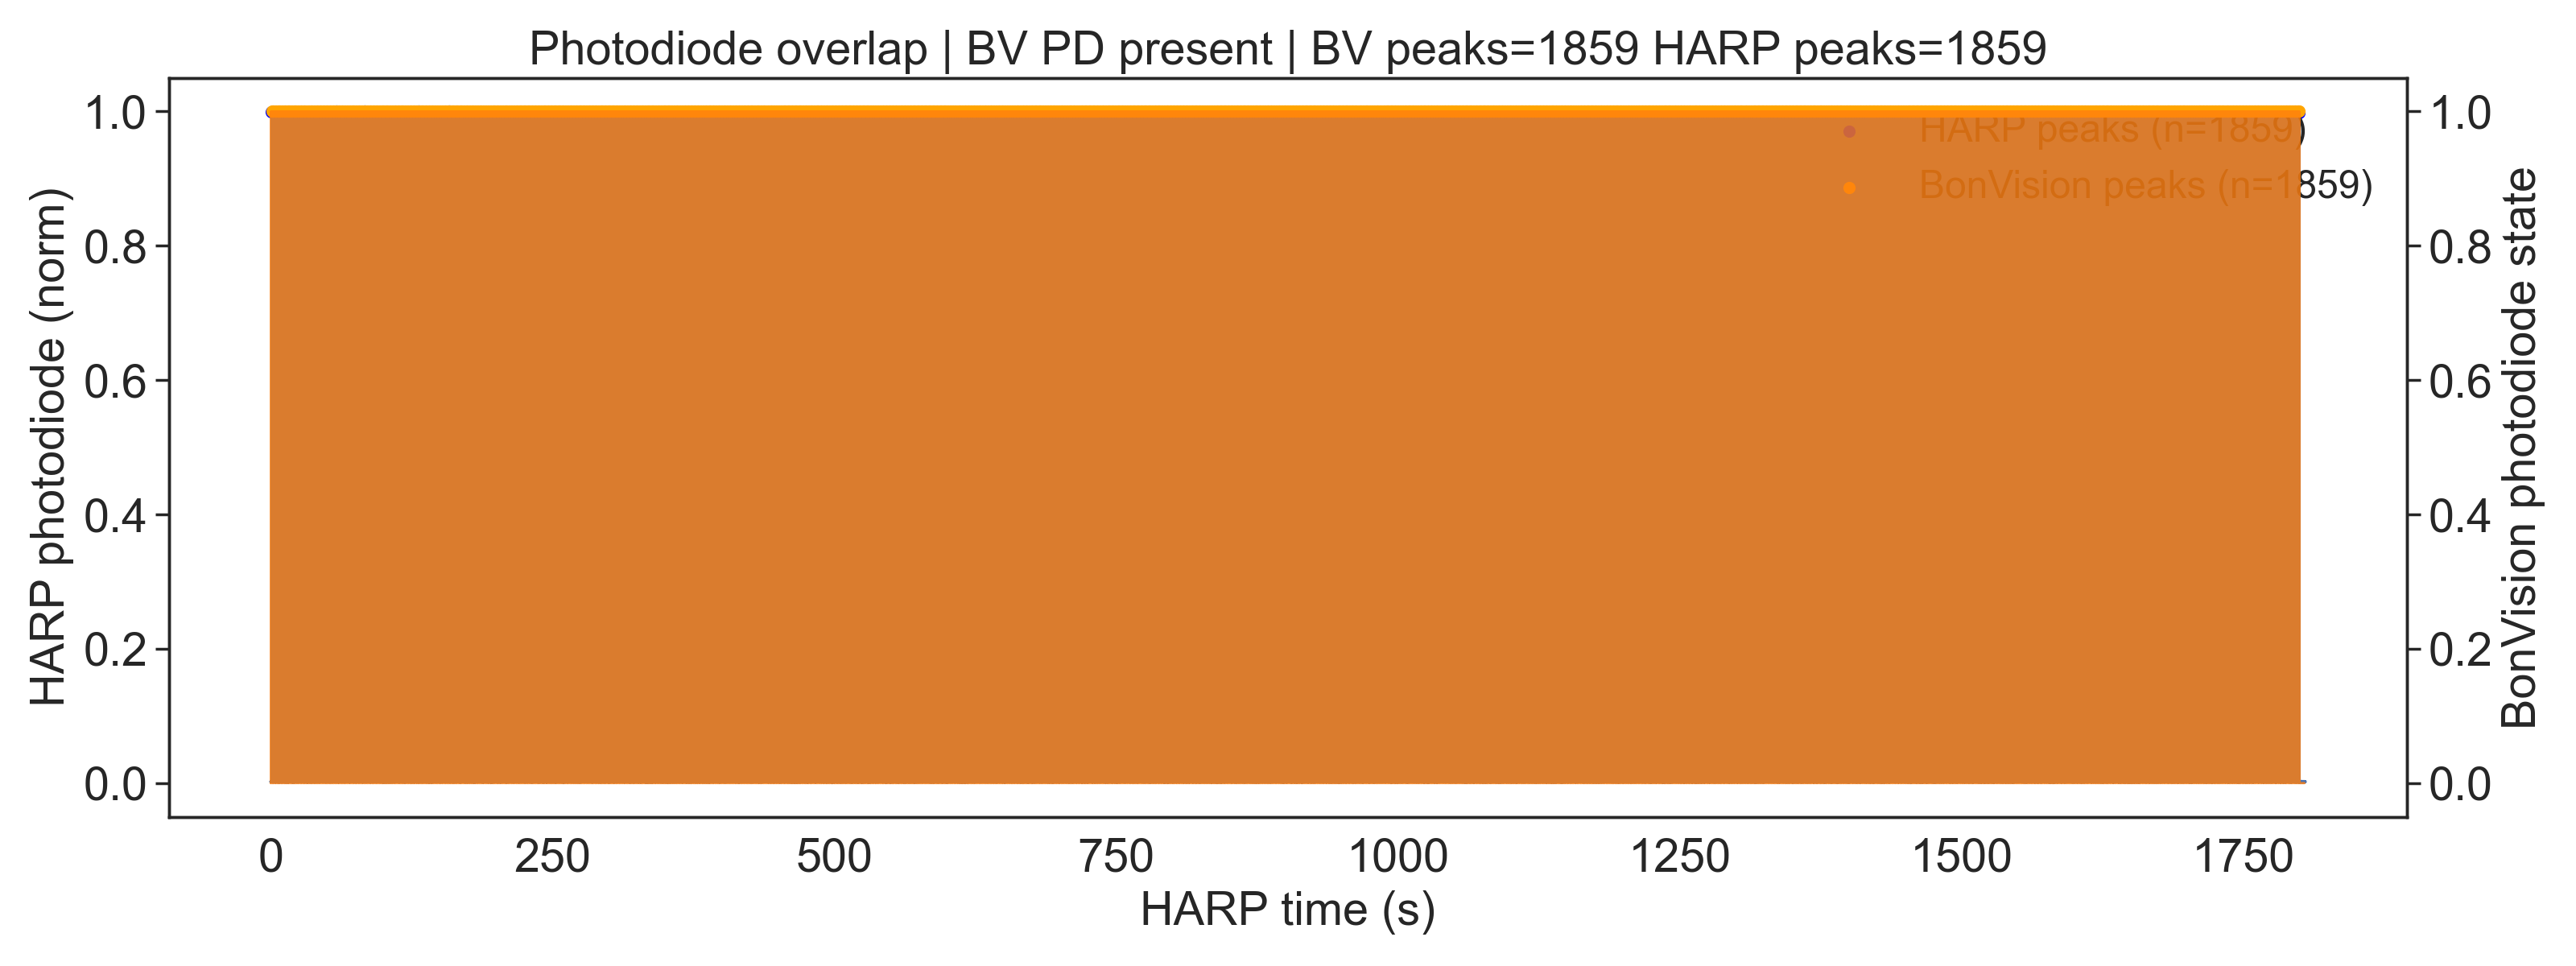


=== 838410_2026-03-03_13-49-07 ===
event_log: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\838410\838410_2026-03-03_13-49-07\838410_2026-03-03_13-49-07\behavior\VCO1_Behavior.harp\bonsai_event_log.csv
photodiode: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\838410\838410_2026-03-03_13-49-07\838410_2026-03-03_13-49-07\behavior\VCO1_Behavior.harp\extracted_files\photodiode.pkl
unique stim IDs (tif/tiff): 7


<IPython.core.display.Javascript object>


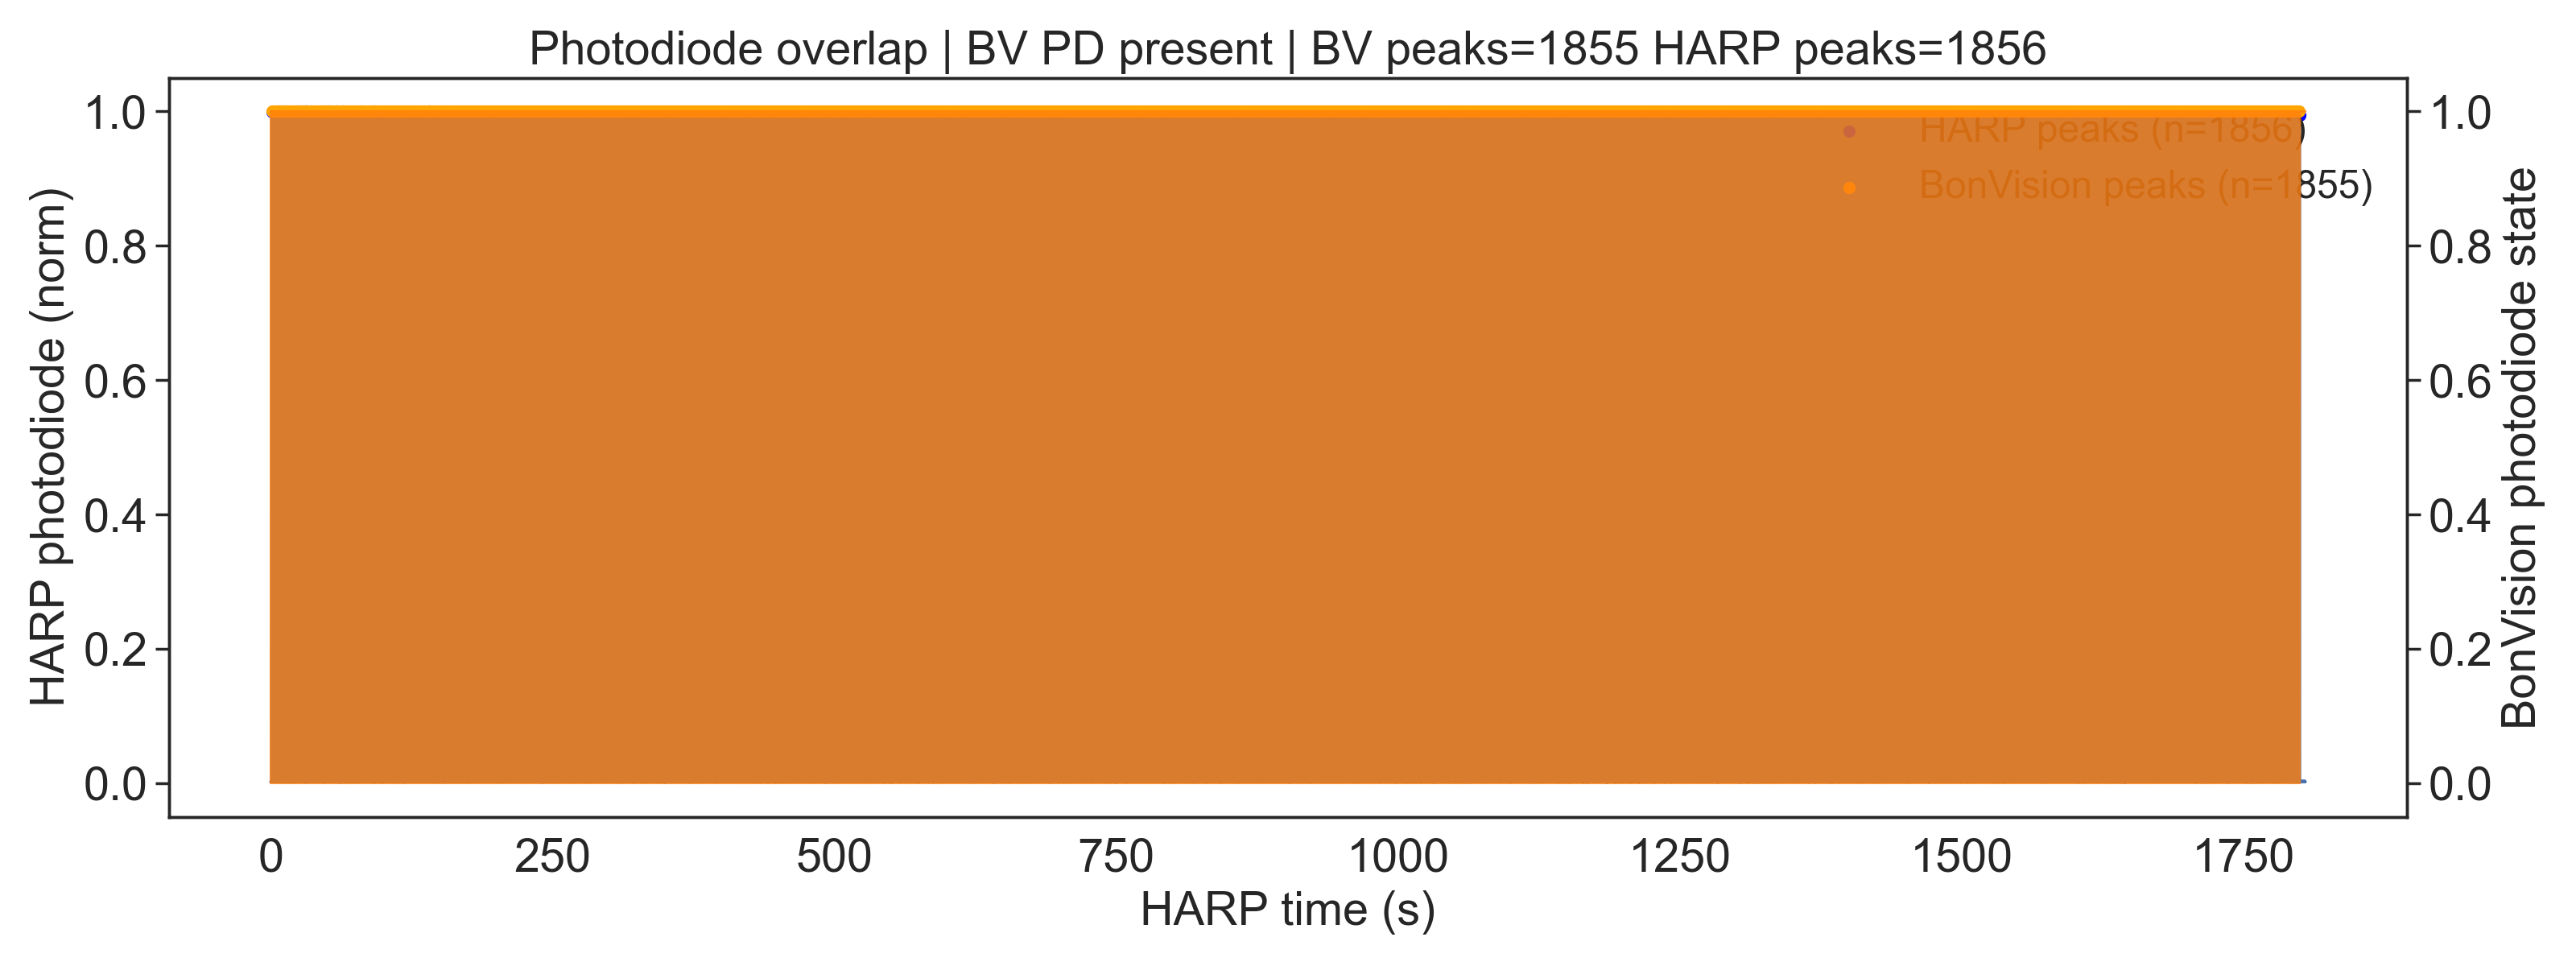


=== 838410_2026-03-04_12-54-47 ===
event_log: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\838410\838410_2026-03-04_12-54-47\838410_2026-03-04_12-54-47\behavior\VCO1_Behavior.harp\bonsai_event_log.csv
photodiode: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\838410\838410_2026-03-04_12-54-47\838410_2026-03-04_12-54-47\behavior\VCO1_Behavior.harp\extracted_files\photodiode.pkl
unique stim IDs (tif/tiff): 7


<IPython.core.display.Javascript object>


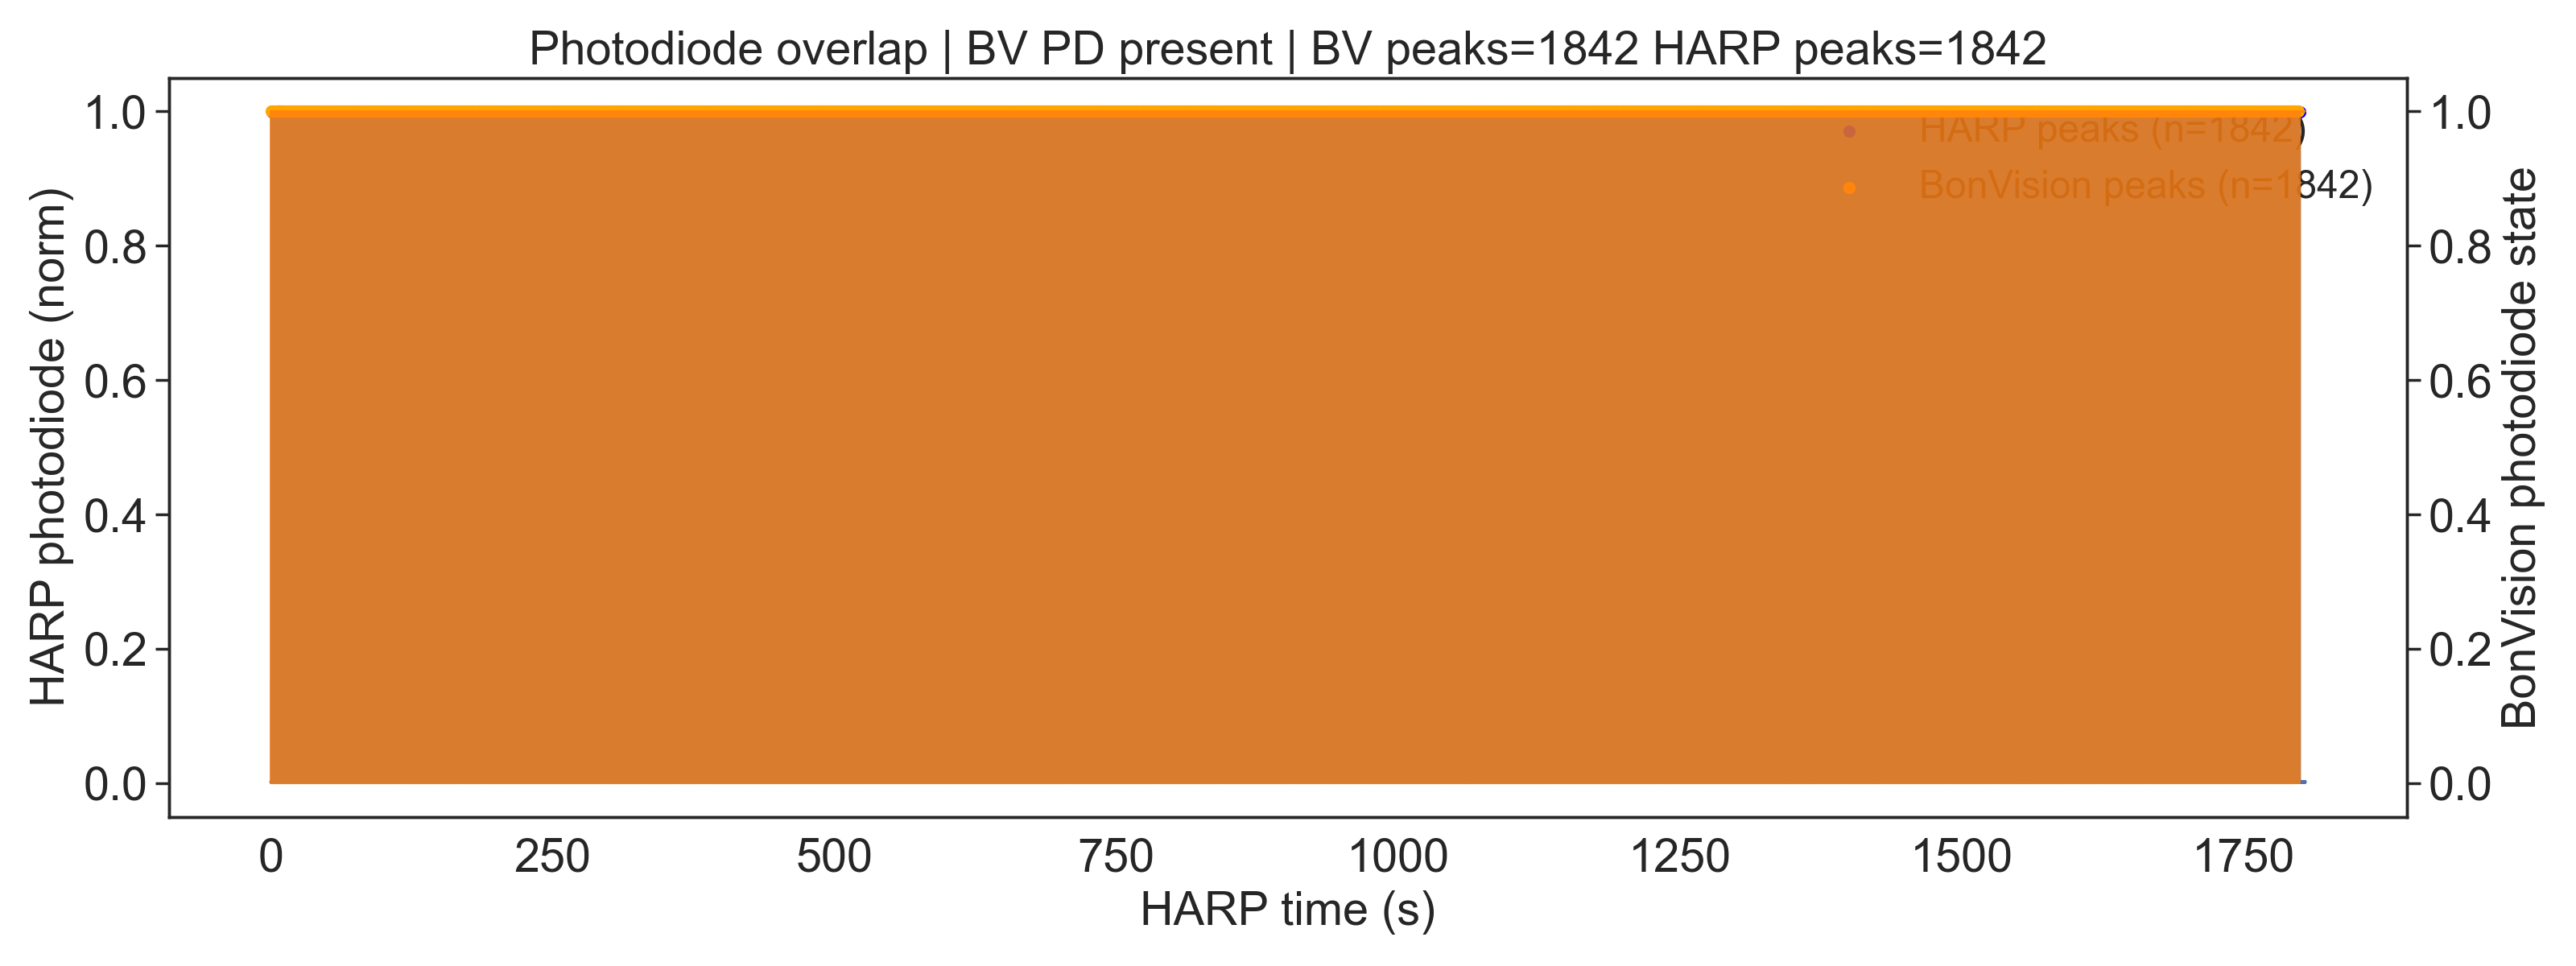


=== 838410_2026-03-05_10-16-37 ===
event_log: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\838410\838410_2026-03-05_10-16-37\838410_2026-03-05_10-16-37\behavior\VCO1_Behavior.harp\bonsai_event_log.csv
photodiode: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\838410\838410_2026-03-05_10-16-37\838410_2026-03-05_10-16-37\behavior\VCO1_Behavior.harp\extracted_files\photodiode.pkl
unique stim IDs (tif/tiff): 7


<IPython.core.display.Javascript object>


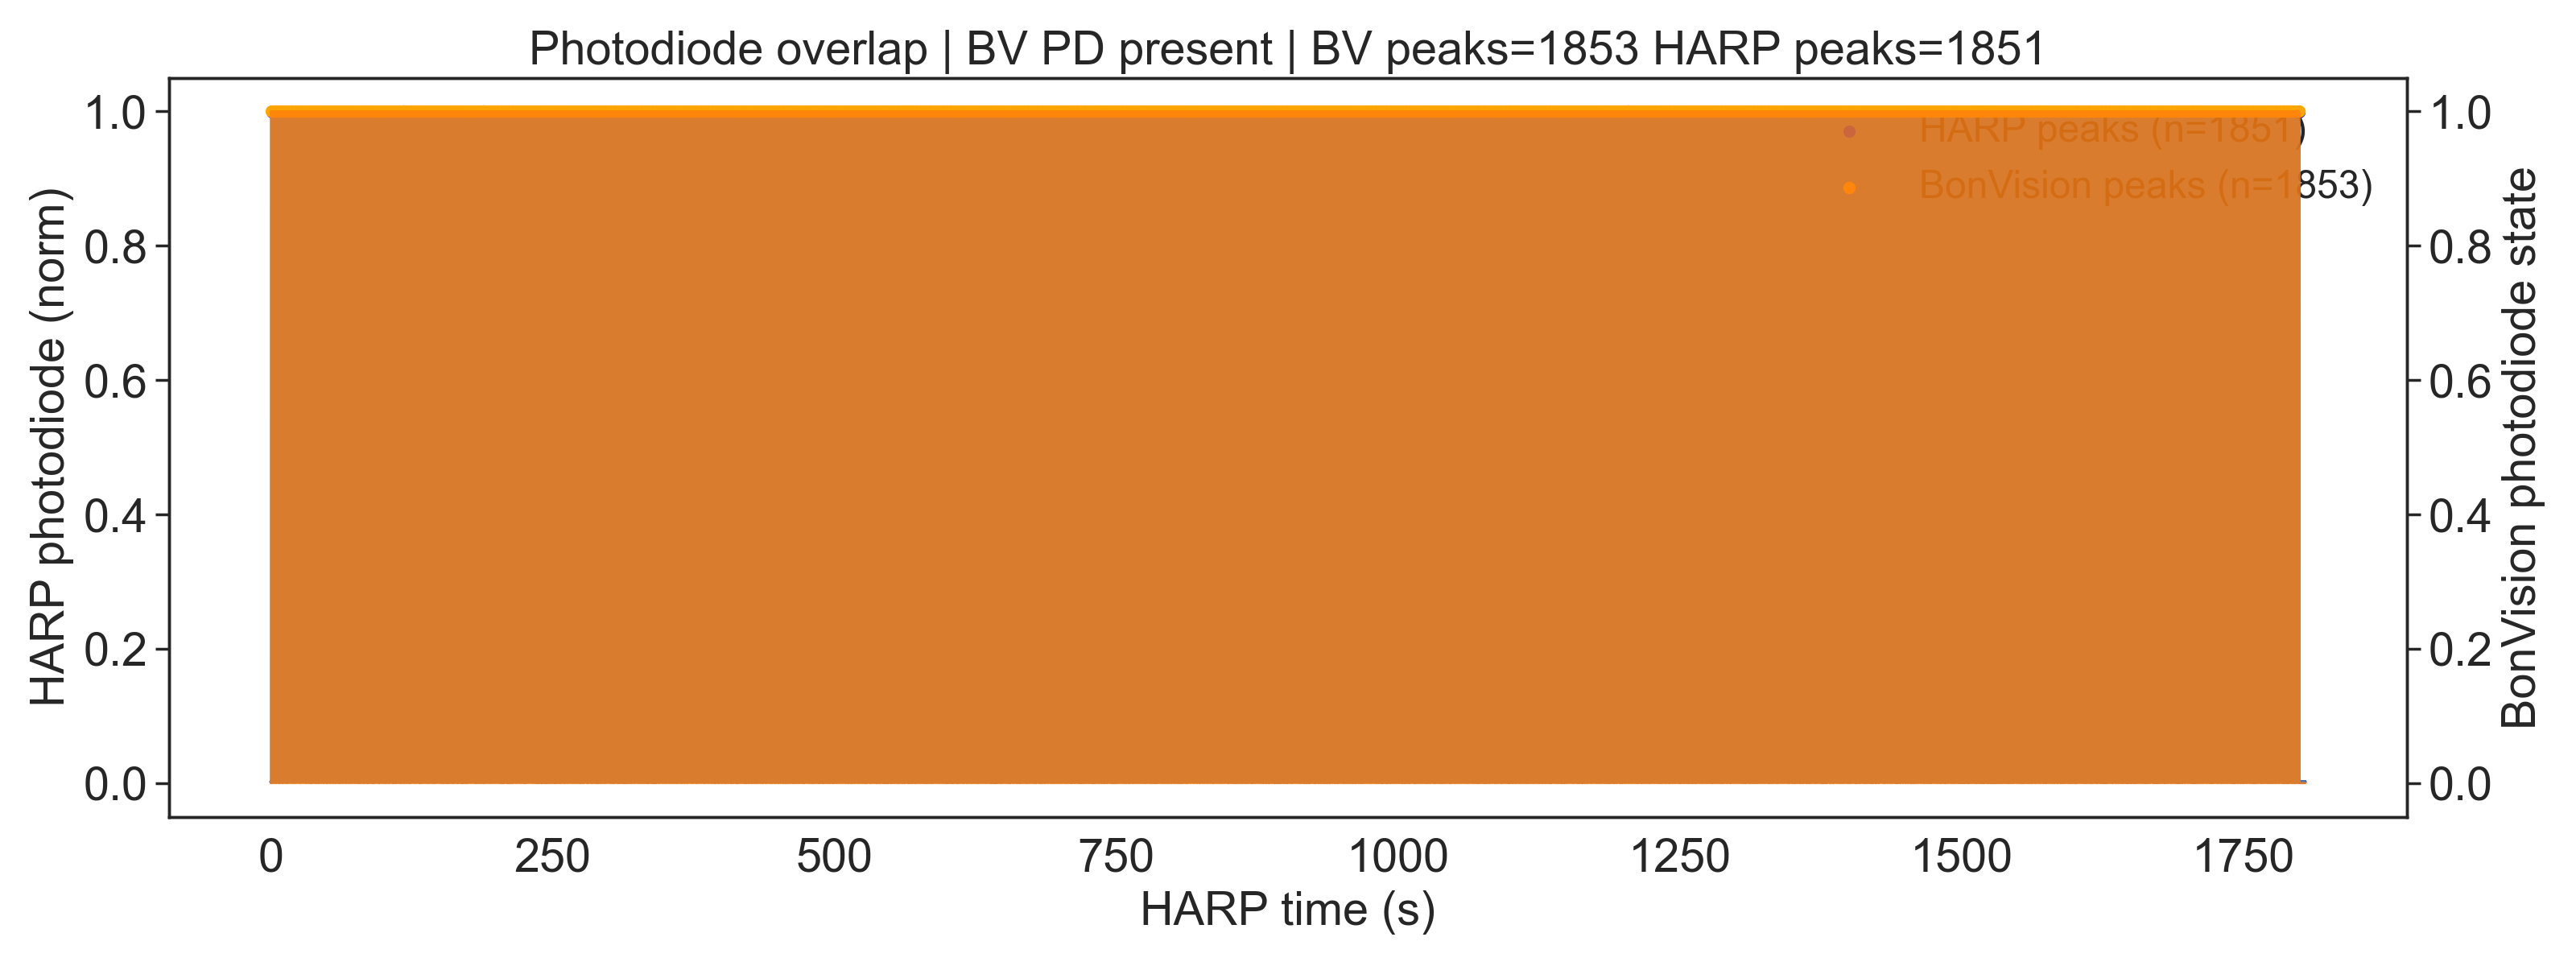


=== 838410_2026-03-18_16-43-23 ===
event_log: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\838410\838410_2026-03-18_16-43-23\838410_2026-03-18_16-43-23\behavior\VCO1_Behavior.harp\bonsai_event_log.csv
photodiode: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\838410\838410_2026-03-18_16-43-23\838410_2026-03-18_16-43-23\behavior\VCO1_Behavior.harp\extracted_files\photodiode.pkl
unique stim IDs (tif/tiff): 7


<IPython.core.display.Javascript object>


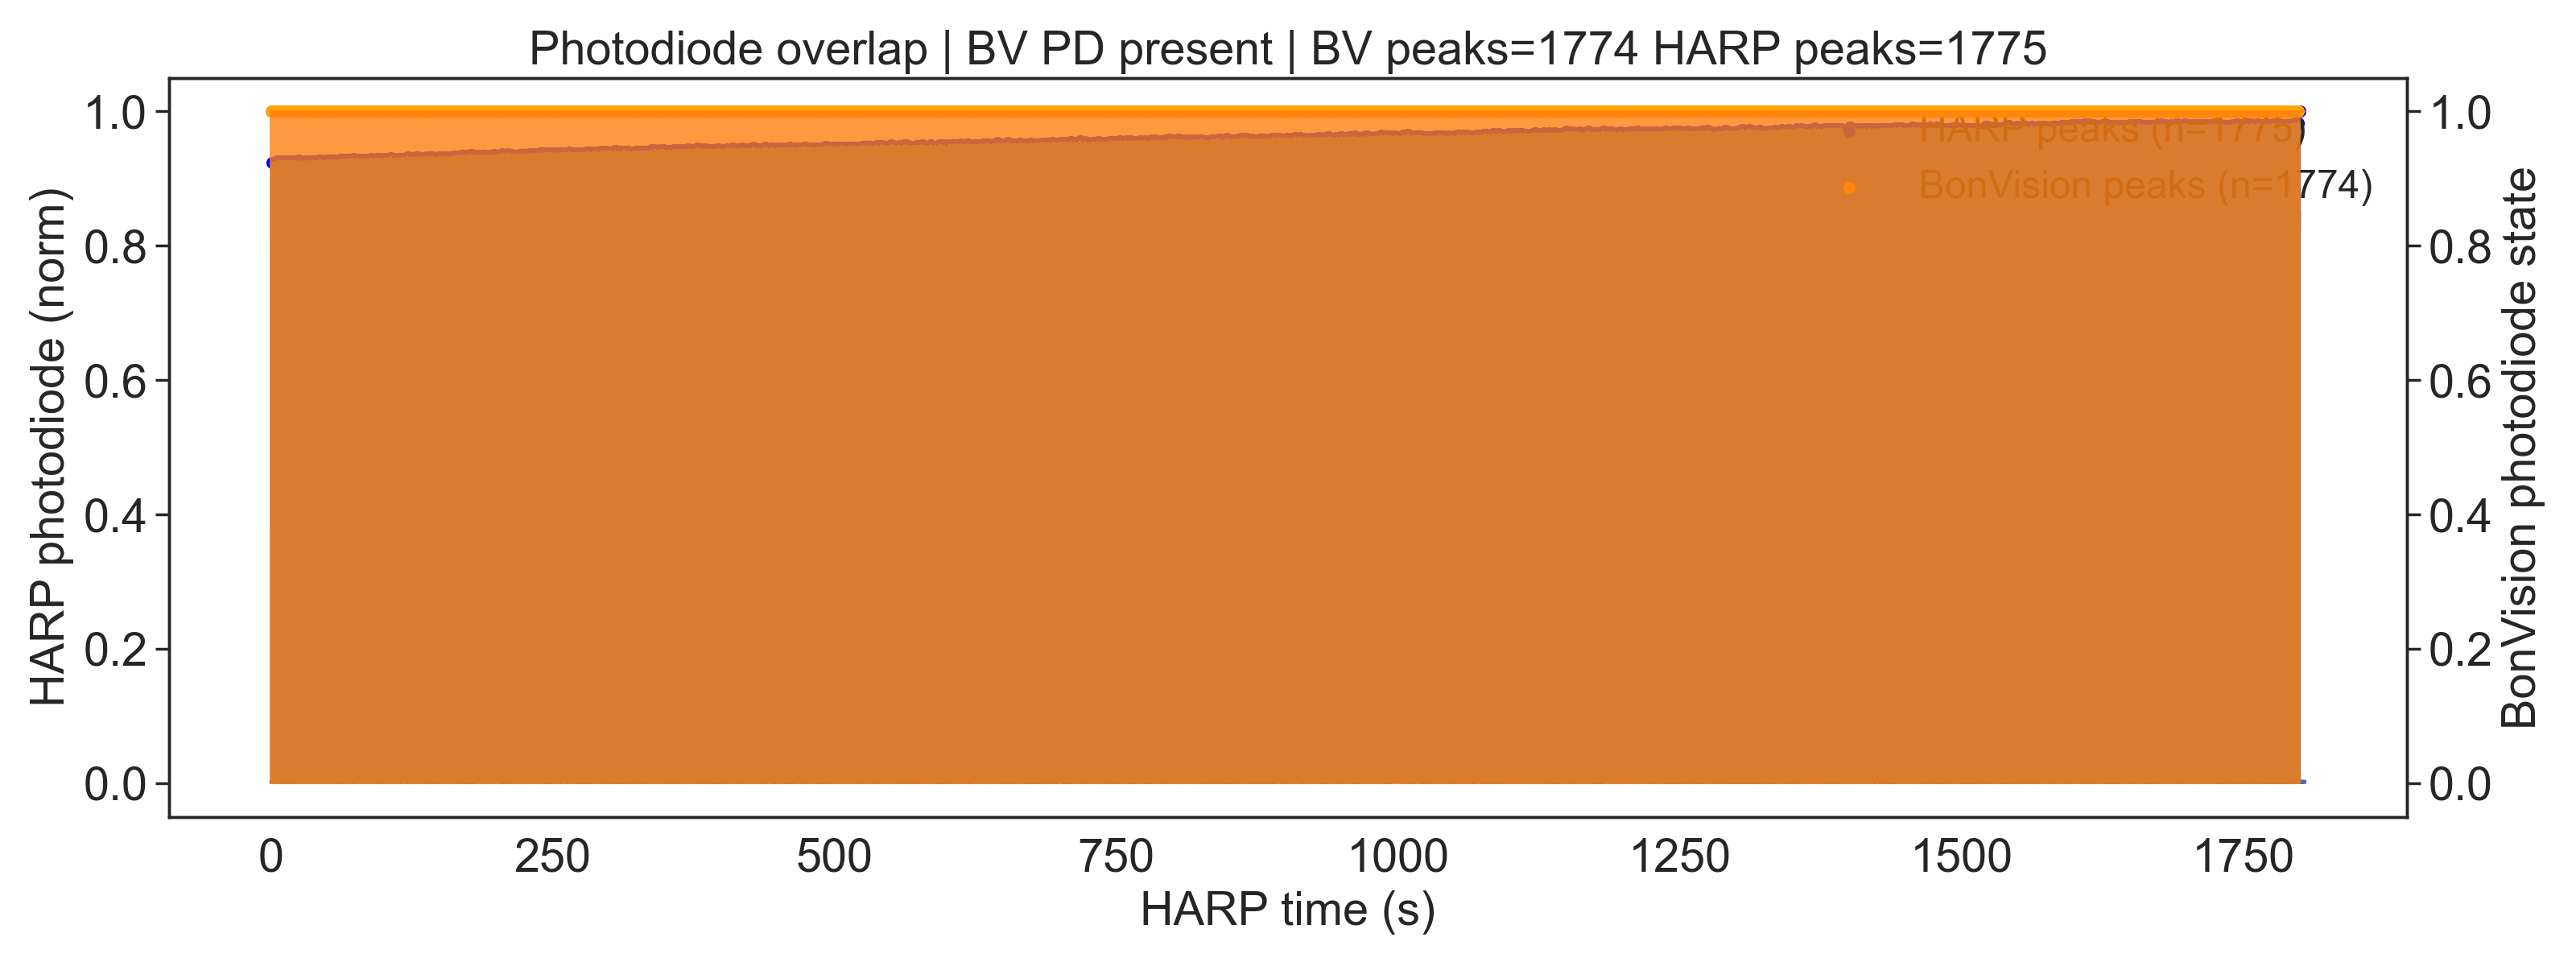


=== 838410_2026-03-19_13-06-48 ===
event_log: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\838410\838410_2026-03-19_13-06-48\838410_2026-03-19_13-06-48\behavior\VCO1_Behavior.harp\bonsai_event_log.csv
photodiode: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\838410\838410_2026-03-19_13-06-48\838410_2026-03-19_13-06-48\behavior\VCO1_Behavior.harp\extracted_files\photodiode.pkl
unique stim IDs (tif/tiff): 7


<IPython.core.display.Javascript object>


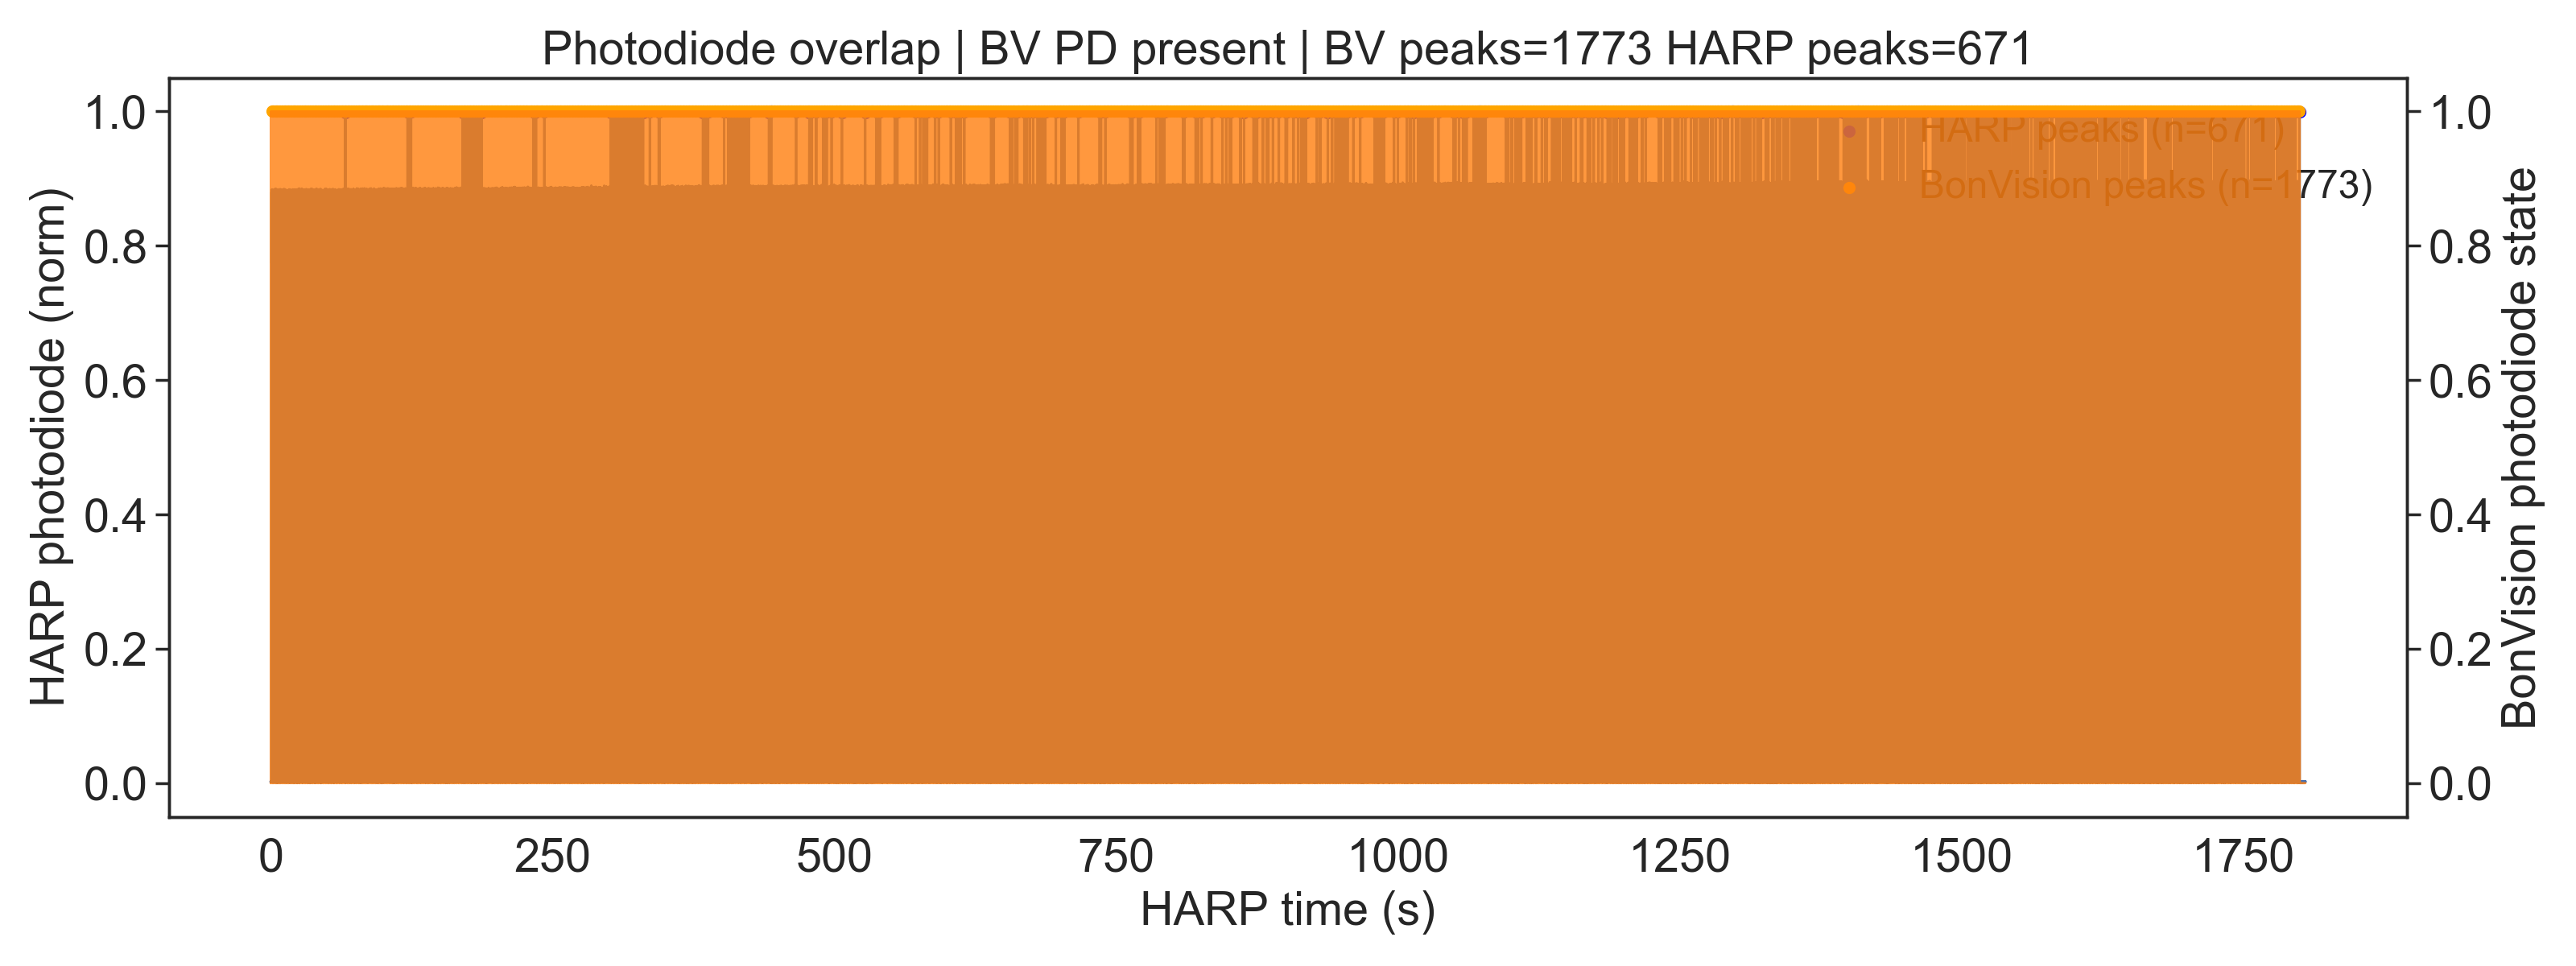


=== 838410_2026-03-20_10-00-59 ===
event_log: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\838410\838410_2026-03-20_10-00-59\838410_2026-03-20_10-00-59\behavior\VCO1_Behavior.harp\bonsai_event_log.csv
photodiode: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\838410\838410_2026-03-20_10-00-59\838410_2026-03-20_10-00-59\behavior\VCO1_Behavior.harp\extracted_files\photodiode.pkl
unique stim IDs (tif/tiff): 7


<IPython.core.display.Javascript object>


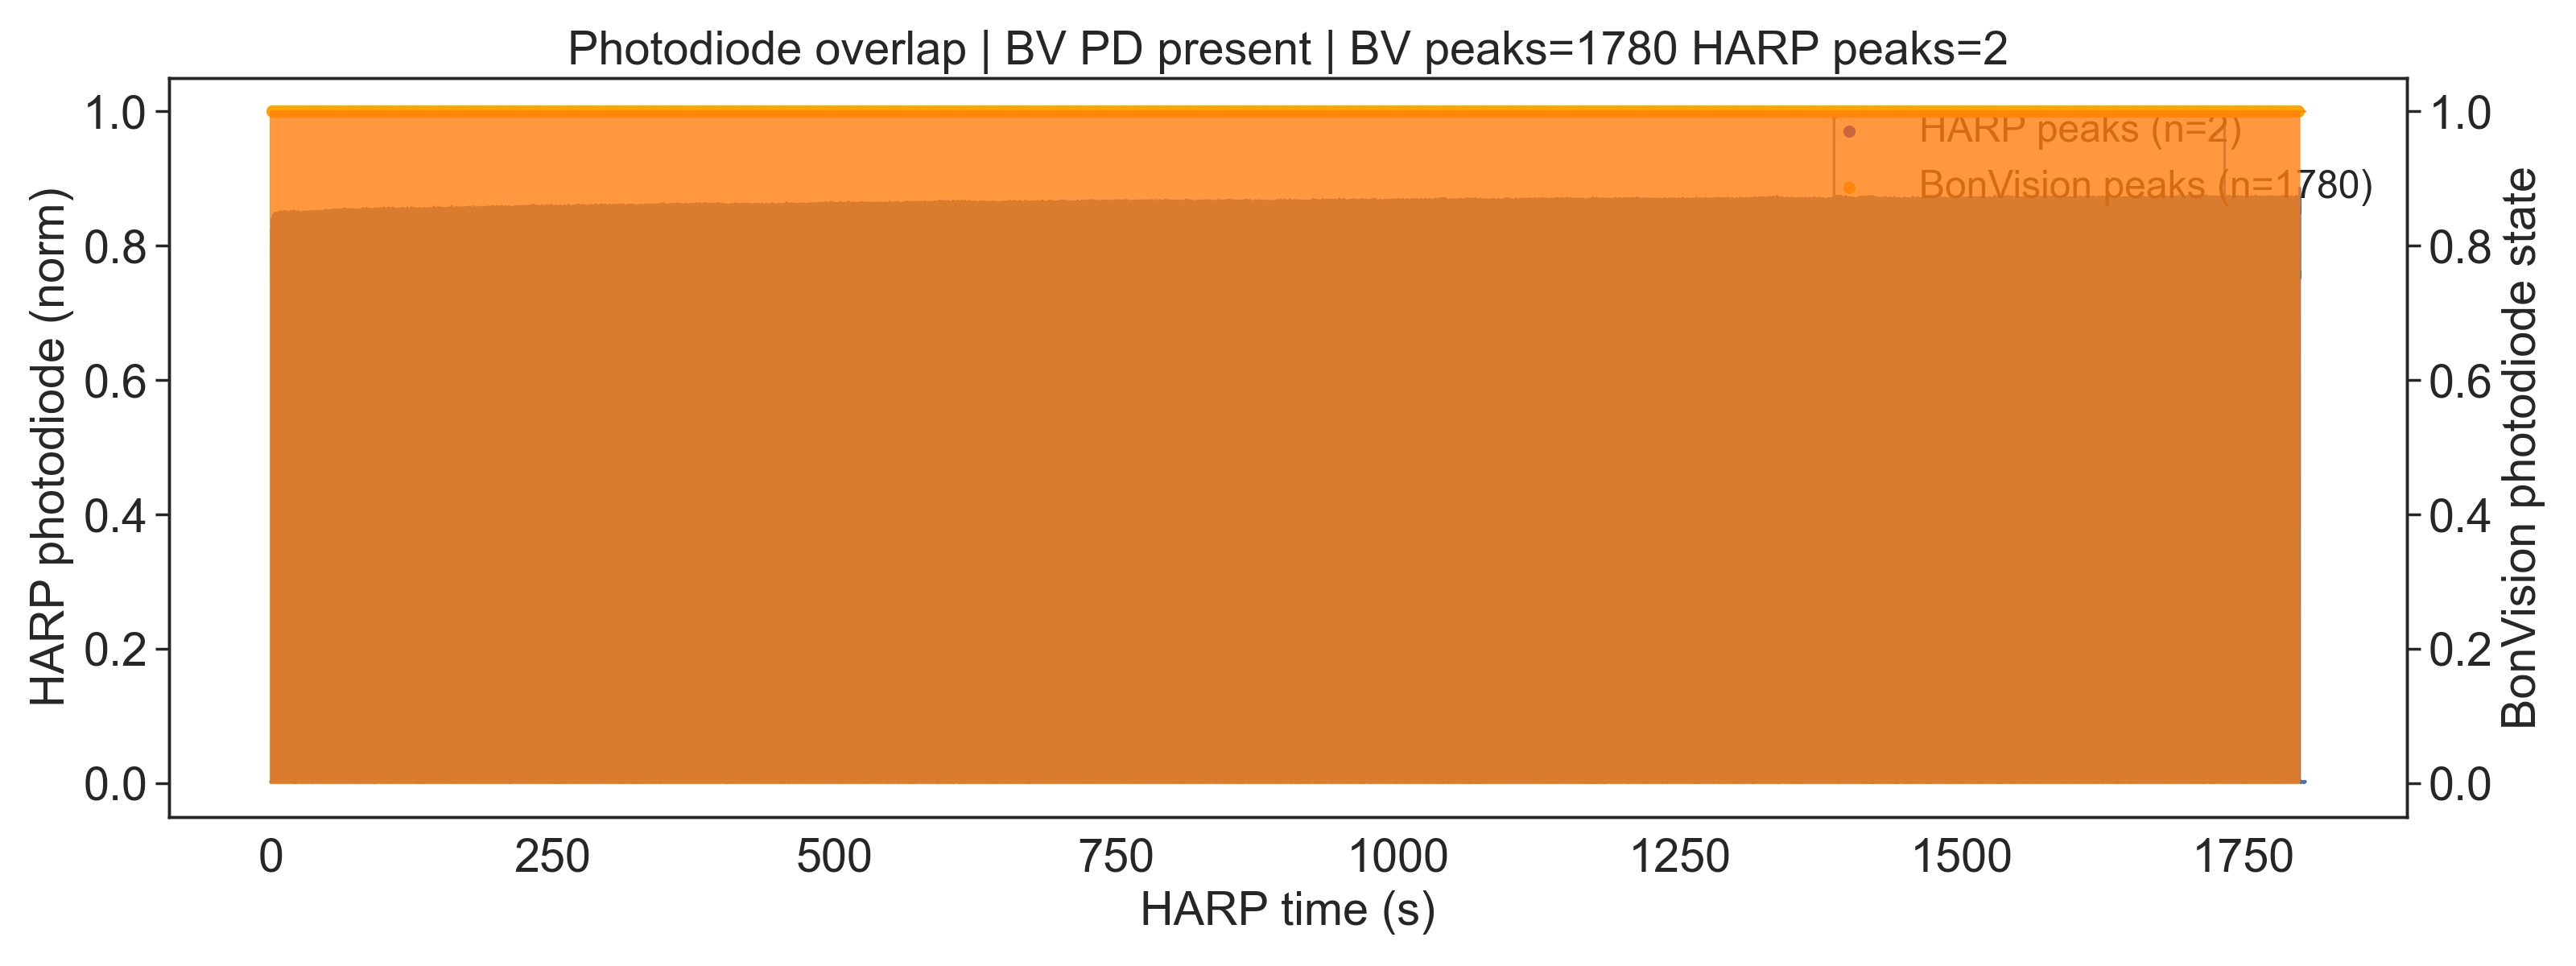

In [10]:
import os, glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# update if needed:
# from vip_slap2_analysis.behavior import preprocess as ps

def normalize(x):
    x = np.asarray(x, dtype=float)
    if np.nanmax(x) == np.nanmin(x):
        return x * 0.0
    return (x - np.nanmin(x)) / (np.nanmax(x) - np.nanmin(x))

bad_sessions = []
plot_fail_sessions = []

for idx, row in process_df.iterrows():
    session_dir = row["session_dir"]
    session_id = row.get("session_id", f"idx{idx}")

    # --- find files
    ev_matches = glob.glob(os.path.join(session_dir, "**", "bonsai_event_log*.csv"), recursive=True)
    if not ev_matches:
        print(f"[SKIP] {session_id}: no bonsai_event_log*.csv under {session_dir}")
        continue
    datapath = Path(ev_matches[0])

    pd_matches = glob.glob(str(datapath.parent / "extracted_files" / "photodiode*.pkl"))
    if not pd_matches:
        print(f"[SKIP] {session_id}: no photodiode*.pkl under {datapath.parent/'extracted_files'}")
        continue
    pd_path = Path(pd_matches[0])

    print(f"\n=== {session_id} ===")
    print(f"event_log: {datapath}")
    print(f"photodiode: {pd_path}")

    # --- load
    stim_df = pd.read_csv(datapath)
    pd_df = pd.read_pickle(pd_path)

    # stimulus ID QC (your original)
    vals = stim_df["Value"].astype(str).values
    num_stim_names = sum(".tif" in v.lower() for v in np.unique(vals))  # catches tif/tiff
    print(f"unique stim IDs (tif/tiff): {num_stim_names}")
    
    corrected_df = stim_df.copy()
    
    pd_df = pd_df.copy()
    pd_df["time_s"] = pd_df.index.values.astype(float) - float(pd_df.index.values.astype(float)[0])
    norm_pd = normalize(pd_df["AnalogInput0"].to_numpy(dtype=float))

    fig, ax = plt.subplots(figsize=(16, 6))

    # 1) HARP photodiode (normalized)
    ax.plot(pd_df["time_s"], norm_pd, linewidth=1)
    ax.set_xlabel("HARP time (s)")
    ax.set_ylabel("HARP photodiode (norm)")

    harp_peaks = find_peaks(norm_pd, distance=700, height=0.9)[0]
    h_sc = ax.scatter(pd_df["time_s"].iloc[harp_peaks], norm_pd[harp_peaks], s=20,color='blue')

    # 2) BV photodiode if present (use corrected_timestamps which are HARP-aligned)
    # corrected_df always has corrected_timestamps; photodiode_state may be all-NaN
    bv_has_pd = ("photodiode_state" in corrected_df.columns) and corrected_df["photodiode_state"].notna().any()
    b_sc = None

    if bv_has_pd:
        # use only frame rows for a clean BV PD step trace
        frame_mask = corrected_df["Value"].astype(str).str.lower().eq("frame")
        bv_t = corrected_df.loc[frame_mask, "corrected_timestamps"].to_numpy(dtype=float)
        bv_pd = corrected_df.loc[frame_mask, "photodiode_state"].ffill().fillna(0.0).to_numpy(dtype=float)

        ax2 = ax.twinx()
        ax2.plot(bv_t, bv_pd, linewidth=1, alpha=0.8,color='tab:orange')
        ax2.set_ylabel("BonVision photodiode state")

        bon_peaks = find_peaks(bv_pd, distance=5, height=1,width=2)[0]
        b_sc = ax2.scatter(bv_t[bon_peaks], bv_pd[bon_peaks], s=20,color='orange')

        title = f"Photodiode overlap | BV PD present | BV peaks={len(bon_peaks)} HARP peaks={len(harp_peaks)}"
    else:
        title = f"Photodiode overlap | BV PD missing | HARP peaks={len(harp_peaks)}"

    ax.set_title(title)
    # Legend
    handles = [h_sc]
    labels = [f"HARP peaks (n={len(harp_peaks)})"]
    if b_sc is not None:
        handles.append(b_sc)
        labels.append(f"BonVision peaks (n={len(bon_peaks)})")

    ax.legend(handles, labels, frameon=False, loc="upper right")
    fig.tight_layout()
    plt.show()